In [ ]:
# This cell sets up the notebook environment for the data preparation and EDA phase.
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    average_precision_score, classification_report, confusion_matrix,
    mean_squared_error, precision_recall_curve, precision_score,
    r2_score, recall_score
)
from sklearn.model_selection import train_test_split, cross_val_score, RandomizedSearchCV
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeRegressor
from xgboost import XGBRegressor, XGBClassifier

import warnings

warnings.filterwarnings('ignore')

sns.set_theme(style="whitegrid")
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 120)

In [2]:
orders = pd.read_csv(f'data/olist_orders_dataset.csv')
items = pd.read_csv(f'data/olist_order_items_dataset.csv')
products = pd.read_csv(f'data/olist_products_dataset.csv')
sellers = pd.read_csv(f'data/olist_sellers_dataset.csv')
customers = pd.read_csv(f'data/olist_customers_dataset.csv')
geolocation = pd.read_csv(f'data/olist_geolocation_dataset.csv')

# Keep payments loaded only because later notebook cells still reference it.
# It is not part of the finalized V1 feature set.
payments = pd.read_csv(f'data/olist_order_payments_dataset.csv')

In [3]:
# This cell removes duplicate rows only from tables that should have one row per key.
unique_key_tables = {
    'orders': 'order_id',
    'customers': 'customer_id',
    'sellers': 'seller_id',
    'products': 'product_id',
}

remove_duplicates_summary = []

# Loop through each table that should have a unique join key.
for table_name, key_col in unique_key_tables.items():
    current_df = globals()[table_name]
    rows_before = len(current_df)
    duplicate_key_rows = current_df.duplicated(subset=key_col).sum()

    # Drop duplicate key rows so later joins do not create accidental duplication.
    current_df = current_df.drop_duplicates(subset=key_col).copy()
    globals()[table_name] = current_df

    remove_duplicates_summary.append({
        'table': table_name,
        'key_checked': key_col,
        'rows_before': rows_before,
        'duplicate_key_rows_found': duplicate_key_rows,
        'rows_after': len(current_df),
    })

pd.DataFrame(remove_duplicates_summary)


,table,key_checked,rows_before,duplicate_key_rows_found,rows_after
0,orders,order_id,99441,0,99441
1,customers,customer_id,99441,0,99441
2,sellers,seller_id,3095,0,3095
3,products,product_id,32951,0,32951


In [4]:
# This cell checks the row grain of the main tables before we start joining them.
table_grain_check = pd.DataFrame([
    {
        'table': 'orders',
        'expected_row_grain': 'one row per order',
        'key_checked': 'order_id',
        'duplicate_key_count': orders['order_id'].duplicated().sum(),
        'interpretation': 'duplicates would be a problem',
    },
    {
        'table': 'items',
        'expected_row_grain': 'one row per item in an order',
        'key_checked': 'order_id',
        'duplicate_key_count': items['order_id'].duplicated().sum(),
        'interpretation': 'expected because one order can contain multiple items',
    },
    {
        'table': 'customers',
        'expected_row_grain': 'one row per customer_id',
        'key_checked': 'customer_id',
        'duplicate_key_count': customers['customer_id'].duplicated().sum(),
        'interpretation': 'duplicates would be a problem',
    },
    {
        'table': 'sellers',
        'expected_row_grain': 'one row per seller_id',
        'key_checked': 'seller_id',
        'duplicate_key_count': sellers['seller_id'].duplicated().sum(),
        'interpretation': 'duplicates would be a problem',
    },
    {
        'table': 'products',
        'expected_row_grain': 'one row per product_id',
        'key_checked': 'product_id',
        'duplicate_key_count': products['product_id'].duplicated().sum(),
        'interpretation': 'duplicates would be a problem',
    },
    {
        'table': 'payments',
        'expected_row_grain': 'one row per payment record',
        'key_checked': 'order_id',
        'duplicate_key_count': payments['order_id'].duplicated().sum(),
        'interpretation': 'expected because one order can use multiple payment records',
    },
])

# Display the table so we can confirm which repeated keys are expected.
table_grain_check


,table,expected_row_grain,key_checked,duplicate_key_count,interpretation
0,orders,one row per order,order_id,0,duplicates would be a problem
1,items,one row per item in an order,order_id,13984,expected because one order can contain multipl...
2,customers,one row per customer_id,customer_id,0,duplicates would be a problem
3,sellers,one row per seller_id,seller_id,0,duplicates would be a problem
4,products,one row per product_id,product_id,0,duplicates would be a problem
5,payments,one row per payment record,order_id,4446,expected because one order can use multiple pa...


In [5]:
# This cell summarizes missing values across the main tables.
source_tables = {
    'orders': orders,
    'items': items,
    'customers': customers,
    'sellers': sellers,
    'products': products,
    'payments': payments,
    'geolocation': geolocation,
}

null_check_rows = []

for table_name, current_df in source_tables.items():
    null_counts = current_df.isna().sum()
    null_counts = null_counts[null_counts > 0]

    # Keep the null details in one row so the result is easier to scan.
    null_check_rows.append({
        'table': table_name,
        'has_nulls': not null_counts.empty,
        'total_nulls': int(null_counts.sum()),
        'null_columns': ', '.join(
            f'{col} ({count})' for col, count in null_counts.items()
        ) if not null_counts.empty else 'none',
    })

null_check_summary = (
    pd.DataFrame(null_check_rows)
    .sort_values(['has_nulls', 'table'], ascending=[False, True])
    .reset_index(drop=True)
)

null_check_summary


,table,has_nulls,total_nulls,null_columns
0,orders,True,4908,"order_approved_at (160), order_delivered_carri..."
1,products,True,2448,"product_category_name (610), product_name_leng..."
2,customers,False,0,none
3,geolocation,False,0,none
4,items,False,0,none
5,payments,False,0,none
6,sellers,False,0,none


In [ ]:
# First we record which cols have to deal with time so that we can convert: string --> datetime objects
order_datetime_cols = [
    'order_purchase_timestamp',
    'order_approved_at',
    'order_delivered_carrier_date',
    'order_delivered_customer_date',
    'order_estimated_delivery_date',
]

orders[order_datetime_cols] = orders[order_datetime_cols].apply(pd.to_datetime) # apply conversion
orders = orders.loc[orders['order_status'].eq('delivered')].copy()
orders = orders.dropna( # drop cols that we cant use 
    subset=[
        'order_purchase_timestamp',
        'order_delivered_customer_date',
        'order_estimated_delivery_date',
    ]
)

purchase_time = orders['order_purchase_timestamp']
delivered_time = orders['order_delivered_customer_date']
estimated_delivery_time = orders['order_estimated_delivery_date']

orders['delay_days'] = ( # keep the exact-timestamp target for optional follow-up analysis
    delivered_time - estimated_delivery_time
).dt.total_seconds().div(86400)
orders['delay_days_date'] = (
    delivered_time.dt.normalize() - estimated_delivery_time.dt.normalize()
).dt.days
orders['is_late'] = (orders['delay_days_date'] > 0).astype(int)
orders['purchase_month'] = purchase_time.dt.month
orders['purchase_dayofweek'] = purchase_time.dt.dayofweek
orders['purchase_hour'] = purchase_time.dt.hour
orders['is_weekend'] = purchase_time.dt.dayofweek.isin([5, 6]).astype(int)
orders['estimated_delivery_time_days'] = (
    estimated_delivery_time - purchase_time
).dt.total_seconds().div(86400)

In [7]:
# This cell outlnes customers_features_df
customer_features_df = customers[[
    'customer_id',
    'customer_state',
    'customer_zip_code_prefix',
]].copy()


In [18]:
# This cell prepares seller geography fields and picks one seller per order for V1 geography features.
seller_features_df = sellers[[
    'seller_id',
    'seller_state',
    'seller_zip_code_prefix',
]].copy()

order_primary_seller_df = (
    items.groupby(['order_id', 'seller_id'], as_index=False)
    .agg(seller_item_count=('order_item_id', 'count'))
    .sort_values(['order_id', 'seller_item_count', 'seller_id'], ascending=[True, False, True])
    .drop_duplicates(subset='order_id')
    [['order_id', 'seller_id']]
    .rename(columns={'seller_id': 'primary_seller_id'})
)

In [19]:
# This cell joins item and product data to put into order_item_agg_df
product_feature_cols = [
    'product_id',
    'product_category_name',
    'product_weight_g',
    'product_length_cm',
    'product_height_cm',
    'product_width_cm',
]

item_product_df = items.merge( # merge item data to product data on product_id
    products[product_feature_cols].copy(),
    on='product_id',
    how='left',
)
item_product_df['product_category_name'] = item_product_df['product_category_name'].fillna('unknown') # fill rows with a missing product_category value with `unknown`
item_product_df['item_volume_cm3'] = ( # calculate feature engineered col
    item_product_df['product_length_cm']
    * item_product_df['product_height_cm']
    * item_product_df['product_width_cm']
)

dominant_category_by_order = (
    item_product_df.groupby('order_id')['product_category_name']
    .agg(lambda s: s.mode().iat[0] if not s.mode().empty else 'unknown')
    .rename('dominant_category')
)

# Final initialization for order_item_agg_df which we can see is ordered by order_id and has both product and item information as we laid it out.
order_item_agg_df = (
    item_product_df.groupby('order_id', as_index=False)
    .agg(
        item_count=('order_item_id', 'count'),
        unique_products=('product_id', 'nunique'),
        unique_sellers=('seller_id', 'nunique'),
        total_price=('price', 'sum'),
        total_freight=('freight_value', 'sum'),
        total_weight=('product_weight_g', lambda s: s.sum(min_count=1)),
        total_volume=('item_volume_cm3', lambda s: s.sum(min_count=1)),
        num_categories=('product_category_name', 'nunique'),
    )
    .merge(dominant_category_by_order.reset_index(), on='order_id', how='left')
)

In [20]:
# This cell prepares payment_features_df and geo_zip_df so later cells can merge payment summaries and ZIP-level coordinates.
payment_features_df = (
    payments.groupby('order_id', as_index=False)
    .agg(
        payment_installments=('payment_installments', 'max'),
        payment_value=('payment_value', 'sum'),
        payment_methods_used=('payment_sequential', 'max'),
    )
)

geo_zip_df = (
    geolocation.groupby('geolocation_zip_code_prefix', as_index=False)
    .agg(
        zip_lat=('geolocation_lat', 'mean'),
        zip_lng=('geolocation_lng', 'mean'),
    )
)

print(f"payment_features_df duplicate order_id count: {payment_features_df['order_id'].duplicated().sum()}")
print(f"geo_zip_df rows: {len(geo_zip_df)}")

In [21]:
# This cell prepares the dataframe: customers_features_df and seller_features_df by merging to geo_zip_df to get lat and lng for the customer and seller ZIP codes. So that we can calculate distance between customer and seller. 
customer_features_df = customer_features_df.merge(
    geo_zip_df.rename(columns={
        'geolocation_zip_code_prefix': 'customer_zip_code_prefix',
        'zip_lat': 'customer_lat',
        'zip_lng': 'customer_lng',
    }),
    on='customer_zip_code_prefix',
    how='left',
)
seller_features_df = seller_features_df.merge(
    geo_zip_df.rename(columns={
        'geolocation_zip_code_prefix': 'seller_zip_code_prefix',
        'zip_lat': 'seller_lat',
        'zip_lng': 'seller_lng',
    }),
    on='seller_zip_code_prefix',
    how='left',
)

In [ ]:
# This cell merges the V1 time, geography, and order-item features into the final model tables.
def haversine(lat1, lon1, lat2, lon2):
    earth_radius_km = 6371
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat / 2) ** 2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2) ** 2
    return earth_radius_km * 2 * np.arctan2(np.sqrt(a), np.sqrt(1 - a))

# outline basic shape for final_modeL_df
final_model_df = orders[[
    'order_id',
    'customer_id',
    'delay_days',
    'delay_days_date',
    'is_late',
    'purchase_month',
    'purchase_dayofweek',
    # 'purchase_hour',
    'is_weekend',
    'estimated_delivery_time_days',
]].copy()

# merge intermediate dataframes to this final df
final_model_df = final_model_df.merge(order_item_agg_df, on='order_id', how='left')
final_model_df = final_model_df.merge(payment_features_df, on='order_id', how='left')
final_model_df = final_model_df.merge(customer_features_df, on='customer_id', how='left')
final_model_df = final_model_df.merge(order_primary_seller_df, on='order_id', how='left')
final_model_df = final_model_df.merge(
    seller_features_df.rename(columns={'seller_id': 'primary_seller_id'}),
    on='primary_seller_id',
    how='left',
)

# calculate same state, and distance and put it into final_model_df 
final_model_df['same_state'] = (
    final_model_df['customer_state'] == final_model_df['seller_state']
).astype(int)
final_model_df['distance_km'] = haversine(
    final_model_df['customer_lat'],
    final_model_df['customer_lng'],
    final_model_df['seller_lat'],
    final_model_df['seller_lng'],
)

# drop columns we dont need anymore for final_model_df
df = final_model_df.copy()
df_clean = final_model_df.drop(columns=[
    'order_id',
    'customer_id',
    'primary_seller_id',
    'customer_zip_code_prefix',
    'seller_zip_code_prefix',
    'customer_lat',
    'customer_lng',
    'seller_lat',
    'seller_lng',
    'num_categories',
    'dominant_category'
]).copy()

In [ ]:
# This cell finishes cleaning df_clean and creates baseline_model_df with the payment summary fields included.
df_clean['total_weight'] = df_clean['total_weight'].fillna(df_clean['total_weight'].median())
df_clean['total_volume'] = df_clean['total_volume'].fillna(df_clean['total_volume'].median())
df_clean['distance_km'] = df_clean['distance_km'].fillna(df_clean['distance_km'].median())
df_clean['payment_installments'] = df_clean['payment_installments'].fillna(df_clean['payment_installments'].median())
df_clean['payment_value'] = df_clean['payment_value'].fillna(df_clean['payment_value'].median())
df_clean['payment_methods_used'] = df_clean['payment_methods_used'].fillna(df_clean['payment_methods_used'].median())

baseline_model_df = df_clean.drop(columns=['customer_state', 'seller_state']).copy()

print(baseline_model_df.isna().sum()[baseline_model_df.isna().sum() > 0])
print(baseline_model_df.info())


In [ ]:
# This cell prepares the classification features and targets from baseline_model_df.
TARGET = 'is_late'
REGRESSION_TARGET = 'delay_days_date'
EXCLUDED_TARGETS = ['delay_days', 'delay_days_date', 'is_late']
FEATURES = [col for col in baseline_model_df.columns if col not in EXCLUDED_TARGETS]

X = baseline_model_df[FEATURES].copy()
y = baseline_model_df[TARGET].copy()
y_regression = baseline_model_df[REGRESSION_TARGET].copy()

print(f'Baseline rows:     {baseline_model_df.shape[0]}')
print(f'Baseline features: {len(FEATURES)}')
print(f'Late rate:         {y.mean():.2%}')
print(FEATURES)

In [ ]:
# This cell summarizes the day-level delivery outcome and compares late rates for same_state groups.
delay_summary = pd.Series({
    'early_rate': (baseline_model_df['delay_days_date'] < 0).mean(),
    'on_time_rate': (baseline_model_df['delay_days_date'] == 0).mean(),
    'late_rate': (baseline_model_df['delay_days_date'] > 0).mean(),
    'mean_delay_days': baseline_model_df['delay_days_date'].mean(),
    'median_delay_days': baseline_model_df['delay_days_date'].median(),
})
same_state_delay = (
    baseline_model_df.groupby('same_state')
    .agg(
        order_count=('is_late', 'size'),
        late_rate=('is_late', 'mean'),
        mean_delay_days=('delay_days_date', 'mean'),
        median_delay_days=('delay_days_date', 'median'),
    )
    .reset_index()
)
same_state_delay['same_state_label'] = same_state_delay['same_state'].map({0: 'Different state', 1: 'Same state'})

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sns.histplot(baseline_model_df['delay_days_date'], bins=60, ax=axes[0], color='#d77a61')
axes[0].axvline(0, color='black', linestyle='--', linewidth=1)
axes[0].set_title('Distribution of delay_days_date')
axes[0].set_xlabel('delay_days_date')

sns.barplot(
    data=same_state_delay,
    x='late_rate',
    y='same_state_label',
    ax=axes[1],
    color='#6c8ead',
)
axes[1].set_title('Late Rate by same_state')
axes[1].set_xlabel('Late rate')
axes[1].set_ylabel('same_state')

plt.tight_layout()
delay_summary, same_state_delay

In [ ]:
# This cell shows baseline correlations with is_late after adding the payment summary fields.
correlation_to_late = (
    baseline_model_df.corr(numeric_only=True)['is_late']
    .drop(labels=['delay_days', 'delay_days_date', 'is_late'], errors='ignore')
    .sort_values(key=lambda s: s.abs(), ascending=False)
)
top_corr_features = correlation_to_late.head(15).index.tolist()

plt.figure(figsize=(10, 8))
sns.heatmap(
    baseline_model_df[['is_late'] + top_corr_features].corr(),
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
)
plt.title('Top Baseline Correlations with is_late')
plt.tight_layout()
correlation_to_late.head(15)

In [ ]:
# This cell focuses on the payment features in baseline_model_df so we can see whether they add useful signal to is_late.
payment_correlation_table = correlation_to_late[
    correlation_to_late.index.isin(['payment_installments', 'payment_value', 'payment_methods_used'])
].sort_values()

plt.figure(figsize=(8, 4))
sns.barplot(
    x=payment_correlation_table.values,
    y=payment_correlation_table.index,
    orient='h',
    color='#8fbc8f',
)
plt.axvline(0, color='black', linewidth=1)
plt.title('Payment Feature Correlations with is_late')
plt.xlabel('Correlation with is_late')
plt.ylabel('Payment feature')
plt.tight_layout()
payment_correlation_table

In [ ]:
# This cell creates a stratified train/test split for the late-risk classification task.
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y,
)

print(f'Train rows:       {X_train.shape[0]}')
print(f'Test rows:        {X_test.shape[0]}')
print(f'Train late rate:  {y_train.mean():.2%}')
print(f'Test late rate:   {y_test.mean():.2%}')

In [ ]:
# This cell fits baseline and nonlinear classifiers and stores their test-set probabilities.
models = {
    'dummy_prior': DummyClassifier(strategy='prior'),
    'logistic_balanced': make_pipeline(
        StandardScaler(),
        LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42),
    ),
    'random_forest_balanced': RandomForestClassifier(
        n_estimators=300,
        min_samples_leaf=5,
        class_weight='balanced',
        random_state=42,
        n_jobs=1,
    ),
}

trained_models = {}
test_probabilities = {}

for model_name, model in models.items():
    model.fit(X_train, y_train)
    trained_models[model_name] = model
    test_probabilities[model_name] = model.predict_proba(X_test)[:, 1]

list(trained_models)

In [ ]:
# This cell compares classifiers at the default 0.50 threshold using PR-focused metrics.
def summarize_classifier(y_true, y_prob, threshold=0.50):
    y_pred = (y_prob >= threshold).astype(int)
    metrics = {
        'threshold': threshold,
        'pr_auc': average_precision_score(y_true, y_prob),
        'precision': precision_score(y_true, y_pred, zero_division=0),
        'recall': recall_score(y_true, y_pred, zero_division=0),
        'predicted_positive_rate': y_pred.mean(),
    }
    cm = pd.DataFrame(
        confusion_matrix(y_true, y_pred),
        index=['actual_not_late', 'actual_late'],
        columns=['pred_not_late', 'pred_late'],
    )
    return metrics, cm

metric_rows = []
confusion_matrices = {}

for model_name, y_prob in test_probabilities.items():
    metrics, cm = summarize_classifier(y_test, y_prob)
    metrics['model'] = model_name
    metric_rows.append(metrics)
    confusion_matrices[model_name] = cm

metrics_df = (
    pd.DataFrame(metric_rows)
    .sort_values('pr_auc', ascending=False)
    .reset_index(drop=True)
)

metrics_df, confusion_matrices

In [ ]:
# This cell inspects precision-recall tradeoffs for the best non-dummy classifier.
candidate_metrics_df = metrics_df.loc[metrics_df['model'] != 'dummy_prior'].copy()
best_model_name = candidate_metrics_df.iloc[0]['model']
best_model = trained_models[best_model_name]
best_model_probs = test_probabilities[best_model_name]

precision_curve, recall_curve, thresholds = precision_recall_curve(y_test, best_model_probs)
threshold_table = pd.DataFrame({
    'threshold': thresholds,
    'precision': precision_curve[:-1],
    'recall': recall_curve[:-1],
})
threshold_table['f1'] = (
    2 * threshold_table['precision'] * threshold_table['recall']
    / (threshold_table['precision'] + threshold_table['recall'])
)
threshold_table = threshold_table.replace([np.inf, -np.inf], np.nan).dropna().reset_index(drop=True)

best_threshold_row = threshold_table.sort_values('f1', ascending=False).iloc[0]
chosen_threshold = float(best_threshold_row['threshold'])
chosen_predictions = (best_model_probs >= chosen_threshold).astype(int)
chosen_confusion_matrix = pd.DataFrame(
    confusion_matrix(y_test, chosen_predictions),
    index=['actual_not_late', 'actual_late'],
    columns=['pred_not_late', 'pred_late'],
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(threshold_table['threshold'], threshold_table['precision'], label='Precision')
axes[0].plot(threshold_table['threshold'], threshold_table['recall'], label='Recall')
axes[0].plot(threshold_table['threshold'], threshold_table['f1'], label='F1')
axes[0].axvline(chosen_threshold, color='black', linestyle='--', linewidth=1)
axes[0].set_title(f'Threshold Tradeoffs: {best_model_name}')
axes[0].set_xlabel('Threshold')
axes[0].set_ylabel('Score')
axes[0].legend()

sns.histplot(best_model_probs, bins=30, ax=axes[1], color='#d77a61')
axes[1].axvline(chosen_threshold, color='black', linestyle='--', linewidth=1)
axes[1].set_title(f'Predicted Late Probabilities: {best_model_name}')
axes[1].set_xlabel('Predicted probability of lateness')

plt.tight_layout()

print(f'Selected model: {best_model_name}')
print(f'Chosen threshold (max F1 on this split): {chosen_threshold:.3f}')
chosen_confusion_matrix, threshold_table.sort_values('f1', ascending=False).head(10)

In [ ]:
# This cell uses permutation importance to find signal that pairwise correlations can miss.
permutation_result = permutation_importance(
    best_model,
    X_test,
    y_test,
    n_repeats=10,
    random_state=42,
    scoring='average_precision',
    n_jobs=1,
)

feature_importance_df = (
    pd.DataFrame({
        'feature': X_test.columns,
        'importance_mean': permutation_result.importances_mean,
        'importance_std': permutation_result.importances_std,
    })
    .sort_values('importance_mean', ascending=False)
    .head(15)
)

plt.figure(figsize=(9, 6))
sns.barplot(
    data=feature_importance_df,
    x='importance_mean',
    y='feature',
    orient='h',
    color='#8fbc8f',
)
plt.axvline(0, color='black', linewidth=1)
plt.title(f'Permutation Importance ({best_model_name})')
plt.xlabel('Mean importance on average_precision')
plt.ylabel('Feature')
plt.tight_layout()
feature_importance_df

In [ ]:
# This cell tests Model C: retrain the random forest using only the top 8 permutation-importance features.
top_8_features = feature_importance_df['feature'].head(8).tolist()

top8_random_forest = RandomForestClassifier(
    n_estimators=300,
    min_samples_leaf=5,
    class_weight='balanced',
    random_state=42,
    n_jobs=1,
)
top8_random_forest.fit(X_train[top_8_features], y_train)
top8_probs = top8_random_forest.predict_proba(X_test[top_8_features])[:, 1]

full_model_metrics, full_model_cm = summarize_classifier(y_test, test_probabilities['random_forest_balanced'])
top8_model_metrics, top8_model_cm = summarize_classifier(y_test, top8_probs)

ablation_metrics_df = pd.DataFrame([
    {'model': 'random_forest_full_features', **full_model_metrics},
    {'model': 'random_forest_top_8_features', **top8_model_metrics},
]).sort_values('pr_auc', ascending=False).reset_index(drop=True)

ablation_confusion_matrices = {
    'random_forest_full_features': full_model_cm,
    'random_forest_top_8_features': top8_model_cm,
}

print('Top 8 features used in Model C:')
print(top_8_features)
ablation_metrics_df, ablation_confusion_matrices


,model,threshold,pr_auc,precision,recall,predicted_positive_rate
0,random_forest_full_features,0.5,0.208707,0.318408,0.146901,0.031253
1,random_forest_top_8_features,0.5,0.205483,0.302667,0.173680,0.038872


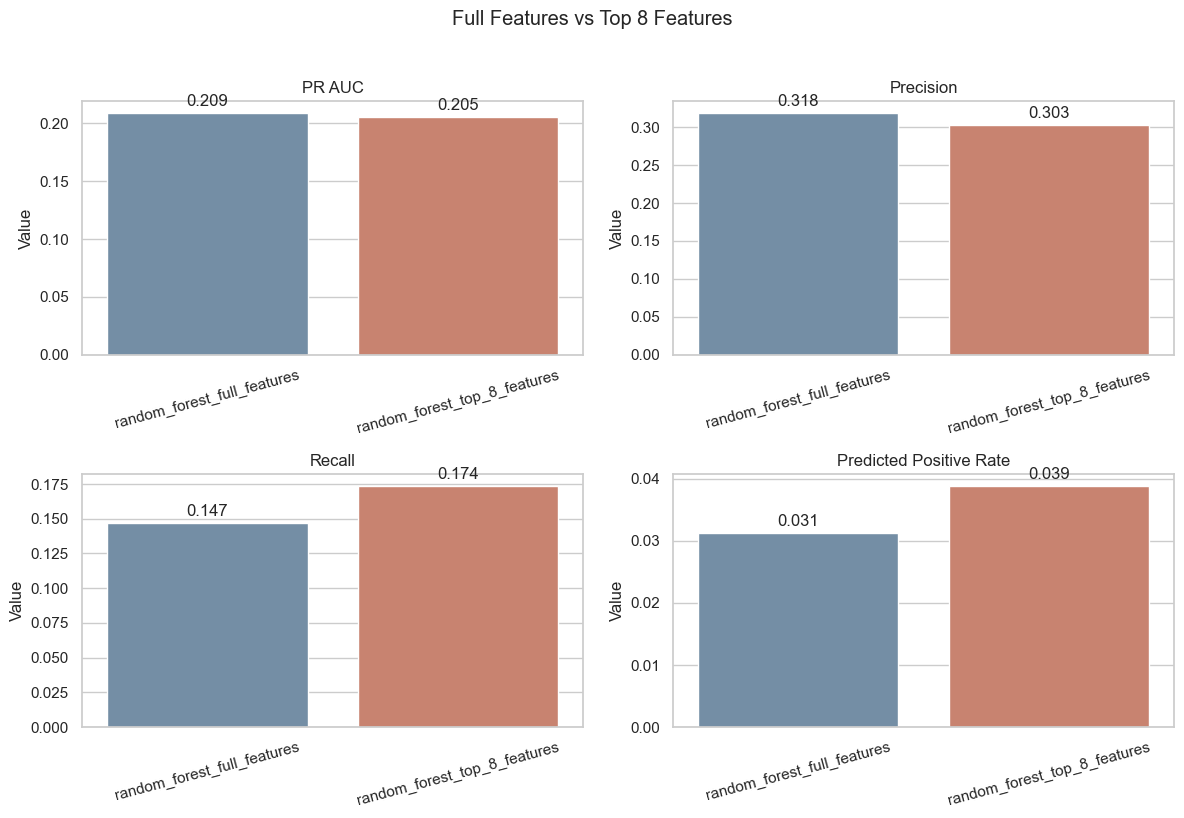

In [101]:
# This cell visualizes whether the top-8-feature model improved versus the full-feature random forest.
comparison_plot_df = ablation_metrics_df[[
    'model',
    'pr_auc',
    'precision',
    'recall',
    'predicted_positive_rate',
]].melt(id_vars='model', var_name='metric', value_name='value')

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
metric_order = ['pr_auc', 'precision', 'recall', 'predicted_positive_rate']
metric_titles = {
    'pr_auc': 'PR AUC',
    'precision': 'Precision',
    'recall': 'Recall',
    'predicted_positive_rate': 'Predicted Positive Rate',
}

for ax, metric in zip(axes.flat, metric_order):
    metric_df = comparison_plot_df[comparison_plot_df['metric'] == metric]
    sns.barplot(data=metric_df, x='model', y='value', ax=ax, palette=['#6c8ead', '#d77a61'])
    ax.set_title(metric_titles[metric])
    ax.set_xlabel('')
    ax.set_ylabel('Value')
    ax.tick_params(axis='x', rotation=15)
    for container in ax.containers:
        ax.bar_label(container, fmt='%.3f', padding=3)

plt.suptitle('Full Features vs Top 8 Features', y=1.02)
plt.tight_layout()
ablation_metrics_df


,feature,importance_mean,importance_std
0,purchase_month,0.105895,0.002052
1,estimated_delivery_time_days,0.070963,0.002925
2,distance_km,0.049666,0.006090
3,same_state,0.028304,0.005531
4,total_freight,0.019869,0.004506
5,total_weight,0.010050,0.002233
6,total_price,0.004660,0.002208
7,total_volume,0.004396,0.002138


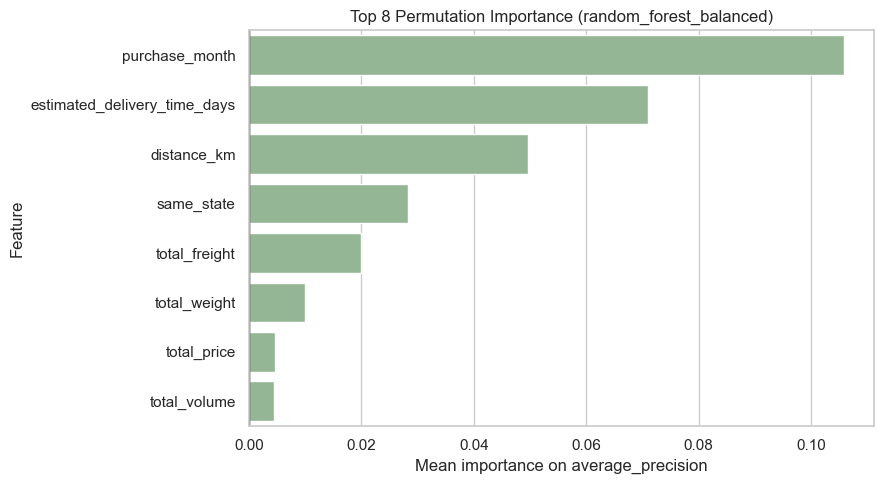

In [102]:
# This cell plots the same permutation-importance visual, filtered to the top 8 selected features.
top_8_importance_df = (
    feature_importance_df[feature_importance_df['feature'].isin(top_8_features)]
    .copy()
    .sort_values('importance_mean', ascending=False)
    .reset_index(drop=True)
)

plt.figure(figsize=(9, 5))
sns.barplot(
    data=top_8_importance_df,
    x='importance_mean',
    y='feature',
    orient='h',
    color='#8fbc8f',
)
plt.axvline(0, color='black', linewidth=1)
plt.title(f'Top 8 Permutation Importance ({best_model_name})')
plt.xlabel('Mean importance on average_precision')
plt.ylabel('Feature')
plt.tight_layout()
top_8_importance_df
